
Final tensile model : Ridge_Stacking
Final roughness model: Ridge_Stacking

Uncertainty columns detected:
Tensile  : Tensile_Total_SD_MPa
Roughness: Roughness_Total_SD_um

OPTIMIZATION BOUNDS


,Feature,Feature_Label,Lower_Bound,Upper_Bound
0,GF_pct,Glass Fiber (%),0.007200,39.996100
1,Infill_pct,Infill Density (%),50.004300,99.991400
2,Layer_mm,Layer Thickness (mm),0.020020,0.399960
3,Nozzle_C,Nozzle Temperature (°C),200.001600,289.977600
4,Bed_C,Bed Temperature (°C),25.010500,109.990100
5,Speed_mm_s,Printing Speed (mm/s),5.021100,99.988400



Final surrogate prediction wrappers: OK

CELL 6 — NOMINAL NSGA-II OPTIMIZATION
   Run 1/3 | seed=20260906
   Run 2/3 | seed=20261007
   Run 3/3 | seed=20261108

CELL 6 — 95% UNCERTAINTY-AWARE ROBUST NSGA-II
   Run 1/3 | seed=20260906
   Run 2/3 | seed=20261007
   Run 3/3 | seed=20261108

Nominal Pareto solutions: 400
Robust Pareto solutions : 342


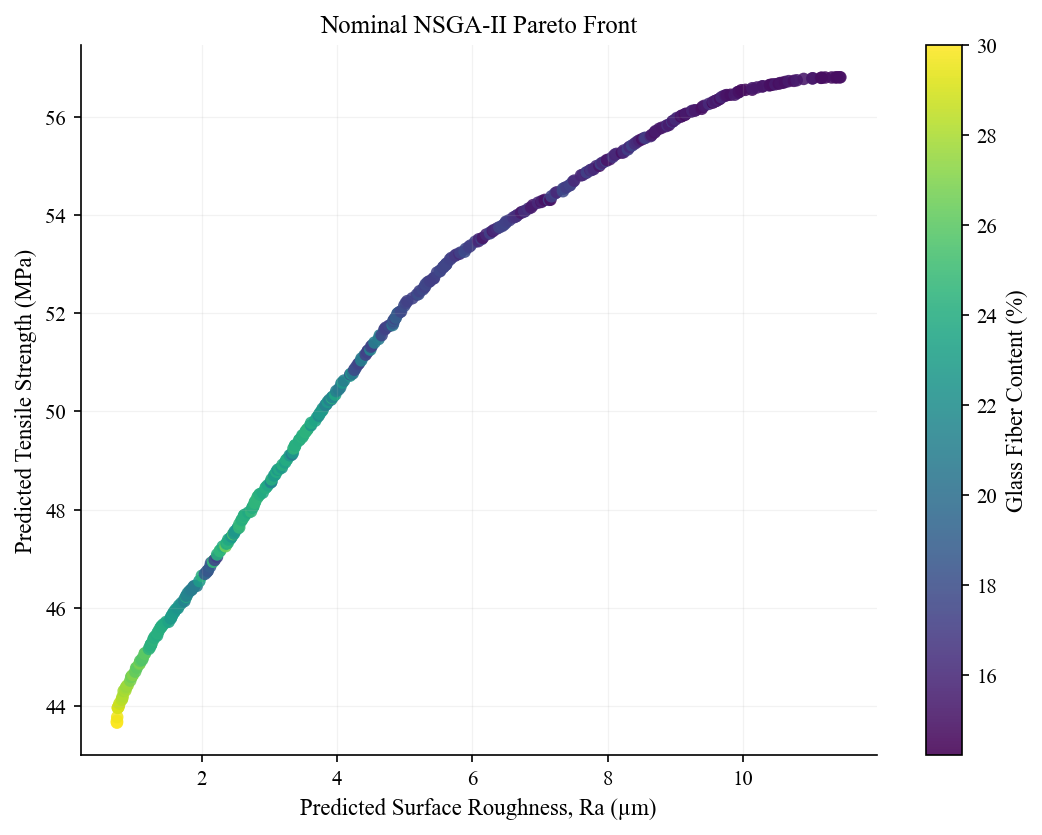

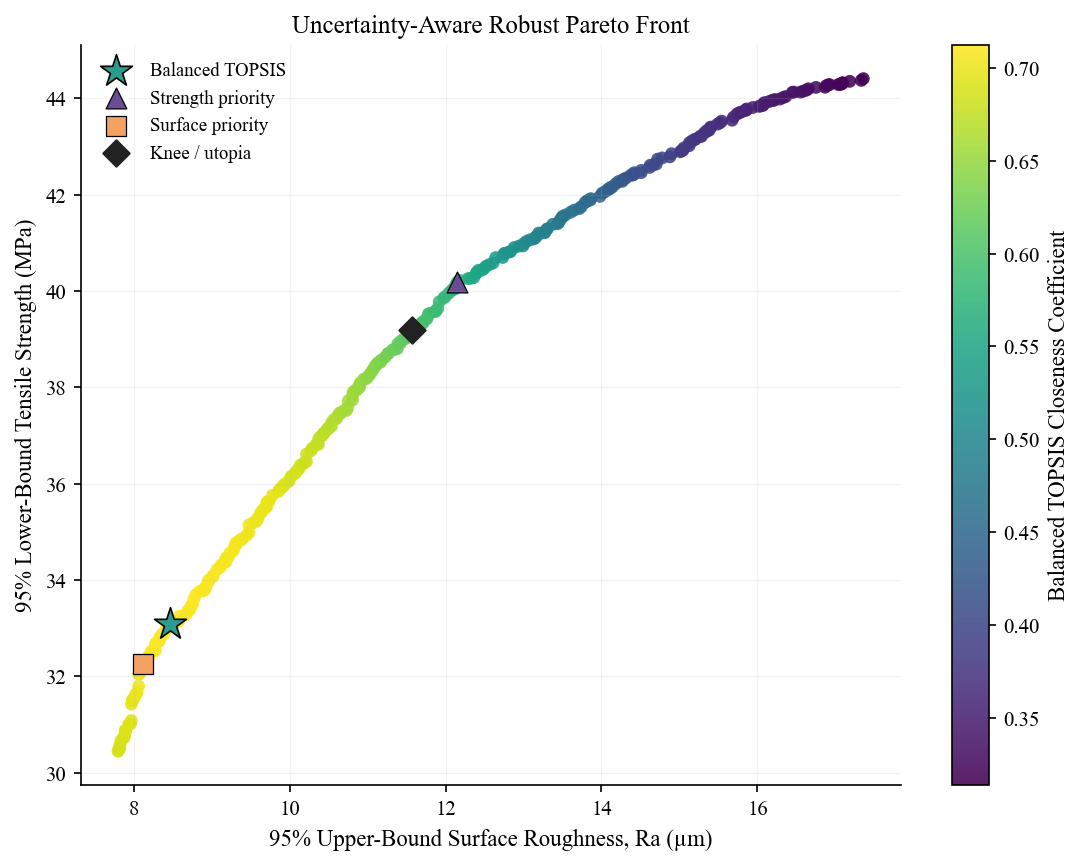

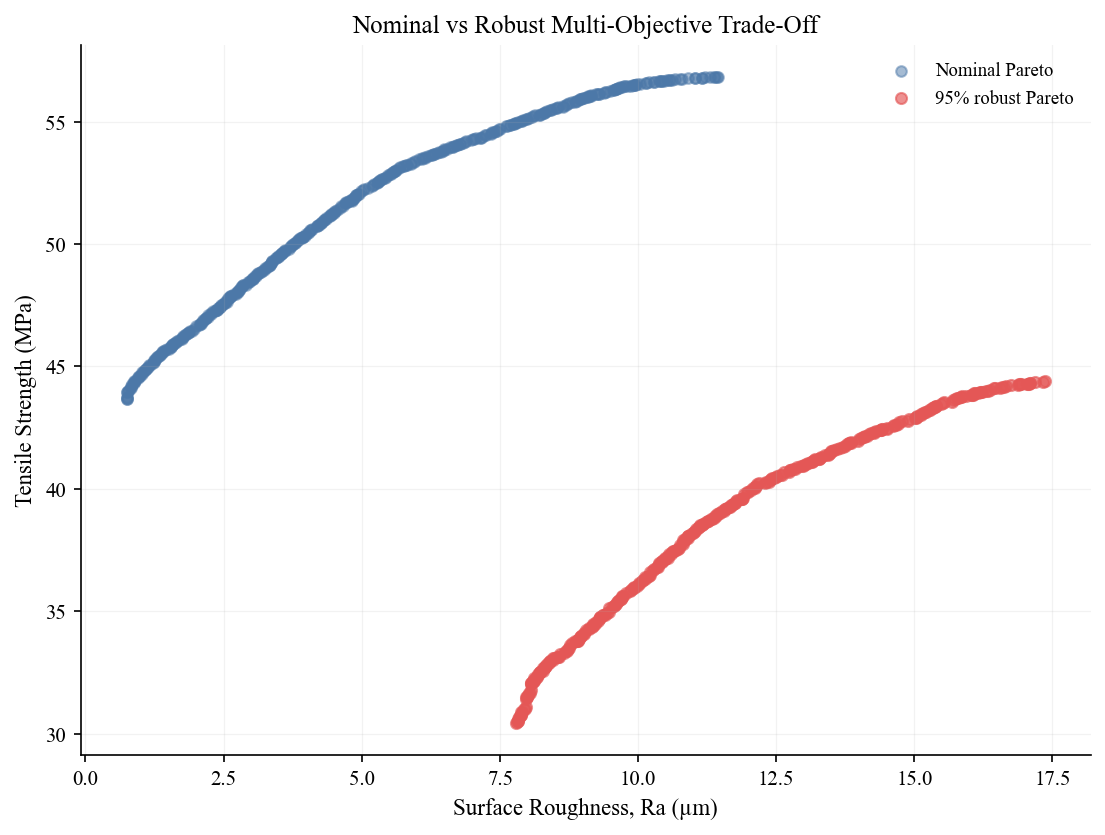

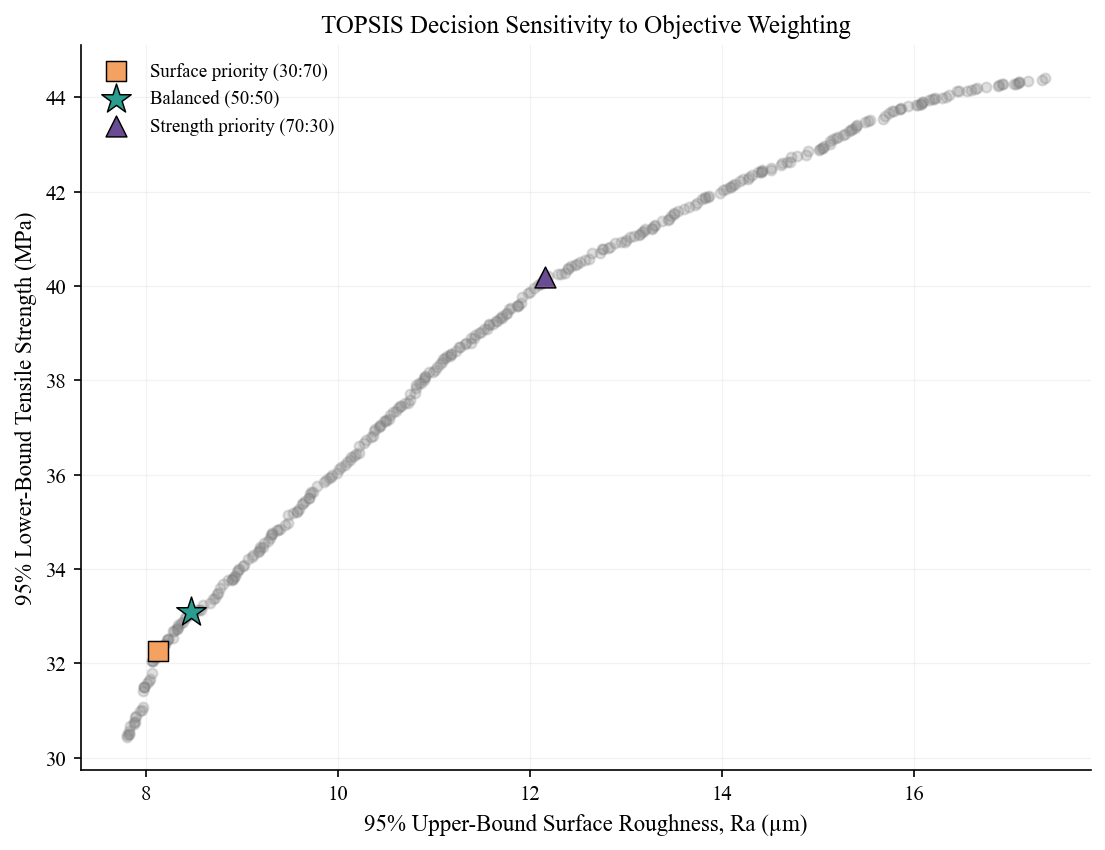

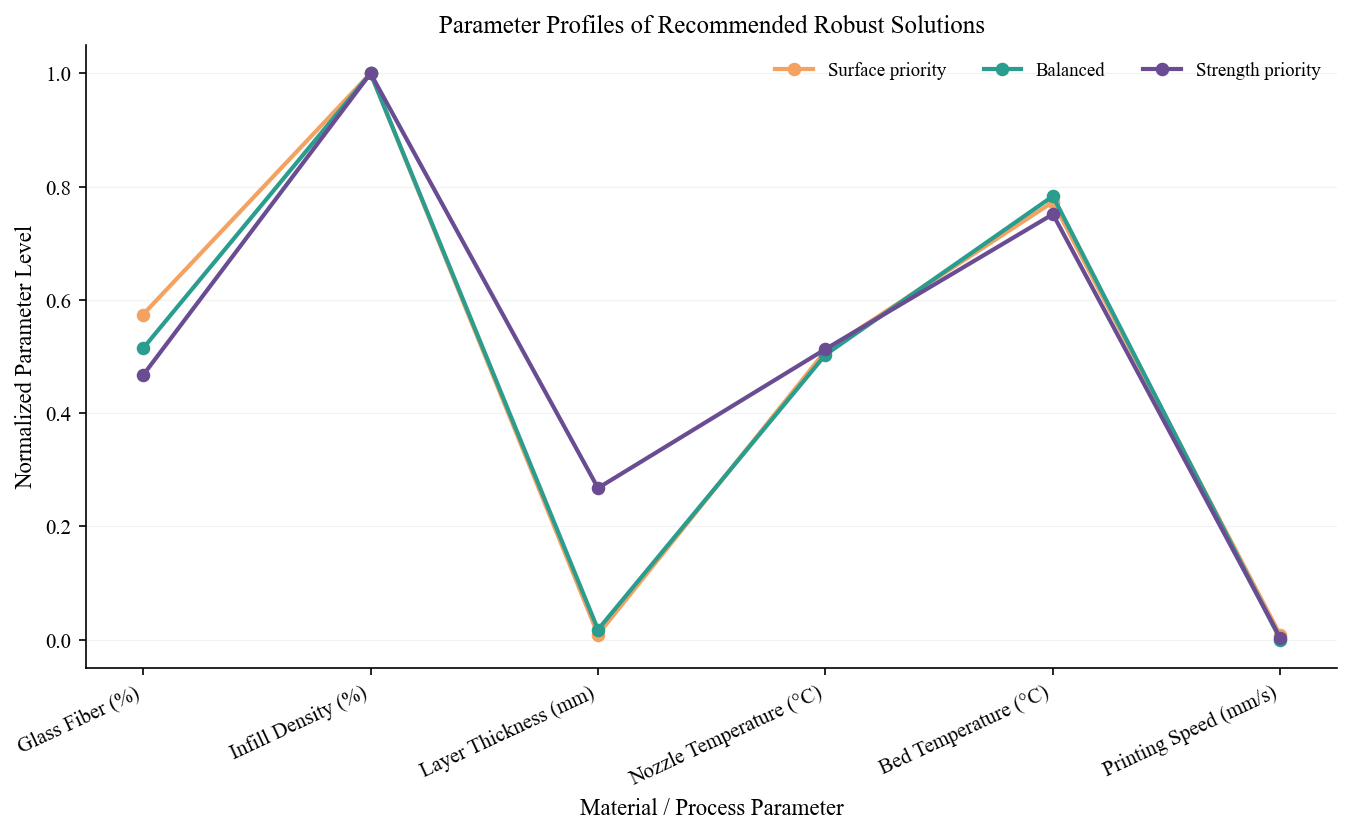

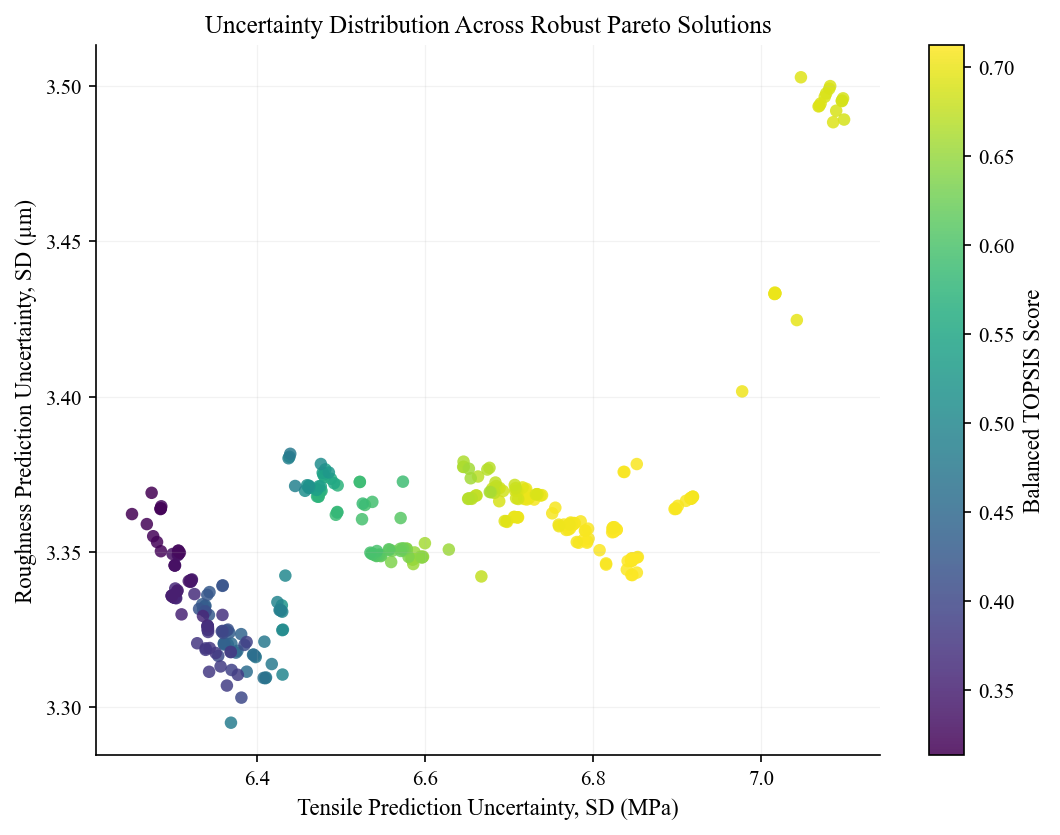


CELL 6 — FINAL MULTI-OBJECTIVE OPTIMIZATION COMPLETE

Nominal Pareto solutions : 400
Robust Pareto solutions  : 342

FINAL BALANCED ROBUST SOLUTION — EXACT SETTINGS
--------------------------------------------------------------------------------------------------------------
Glass Fiber (%)                = 20.577631
Infill Density (%)             = 99.990900
Layer Thickness (mm)           = 0.026825
Nozzle Temperature (°C)        = 245.275082
Bed Temperature (°C)           = 91.561845
Printing Speed (mm/s)          = 5.037760

NOMINAL SURROGATE PERFORMANCE
Tensile Strength       = 46.488356 MPa
Surface Roughness Ra   = 1.905751 µm

95% UNCERTAINTY-AWARE CONSERVATIVE PERFORMANCE
Tensile 95% lower bound  = 33.080258 MPa
Roughness 95% upper bound = 8.466034 µm

Balanced TOPSIS score = 0.712385
Domain support ratio   = 0.950931

PRACTICAL ROUNDED SETTINGS
--------------------------------------------------------------------------------------------------------------
Glass Fiber (%)        

,Confirmation_Run,Selection_Type,GF_pct,Infill_pct,Layer_mm,Nozzle_C,Bed_C,Speed_mm_s,Tensile_Mean_MPa,Tensile_95LCB_MPa,Roughness_Mean_um,Roughness_95UCB_um,Support_Ratio
0,C01,Balanced_TOPSIS,20.500000,99.991400,0.030000,245.000000,92.000000,5.021100,46.652119,33.279711,2.098334,8.678376,0.921895
1,C02,Strength_Priority_TOPSIS,18.500000,99.991400,0.120000,246.000000,89.000000,5.021100,52.857282,40.026590,5.541972,12.163814,0.963637
2,C03,Surface_Priority_TOPSIS,23.000000,99.991400,0.020020,246.000000,91.000000,6.000000,45.619151,32.095221,1.510153,8.102942,1.034414
3,C04,Maximum_Robust_Tensile,16.000000,99.991400,0.150000,246.000000,87.000000,54.000000,56.625600,44.372177,10.615368,17.204825,0.886943
4,C05,Minimum_Robust_Roughness | Pareto_Coverage,27.000000,99.991400,0.020020,246.000000,85.000000,5.021100,44.352287,30.450076,0.984126,7.832555,1.080681
5,C06,Knee_Utopia,18.000000,99.991400,0.100000,247.000000,87.000000,5.021100,51.810097,38.848422,4.842402,11.464472,0.828527
6,C07,Pareto_Coverage,23.000000,99.991400,0.020020,246.000000,90.000000,5.021100,45.580460,31.832852,1.446797,8.186975,1.062331
7,C08,Pareto_Coverage,21.000000,99.991400,0.020020,243.000000,92.000000,5.021100,46.054384,32.635771,1.741482,8.292931,0.984233



TOPSIS WEIGHT-SENSITIVITY


,Strategy,Tensile_Weight,Roughness_Weight,Selected_Pareto_ID,Tensile_95LCB_MPa,Roughness_95UCB_um
0,Surface Priority,0.300000,0.700000,ROB0030,32.256425,8.120855
1,Balanced,0.500000,0.500000,ROB0051,33.080258,8.466034
2,Strength Priority,0.700000,0.300000,ROB0204,40.183703,12.150220



IMPORTANT
No real measured tensile or roughness value has been generated.
Measured columns in the confirmation workbook are intentionally blank.
The optimized solution is a robust optimum of the virtual-response surrogate surface.
Experimental validation is required before claiming a physically validated optimum.

Experimental confirmation template:
C:\Users\apurb\Downloads\Simulation OP ABS\Q1_ML_Output\Cell6_Final_Optimization\Experimental_Confirmation\FINAL_Experimental_Confirmation_Template.xlsx

Master optimization workbook:
C:\Users\apurb\Downloads\Simulation OP ABS\Q1_ML_Output\Cell6_Final_Optimization\Cell6_Final_Optimization_Results.xlsx

All outputs saved to:
C:\Users\apurb\Downloads\Simulation OP ABS\Q1_ML_Output\Cell6_Final_Optimization


In [2]:
# =================================================================================================
# CELL 6 — FINAL MULTI-OBJECTIVE OPTIMIZATION
# COMPLETE REPLACEMENT VERSION
#
# Final Ridge-Stacking surrogates
# NSGA-II
# Nominal Pareto front
# 95% uncertainty-aware robust Pareto front
# TOPSIS
# Knee / utopia solution
# Weight-sensitivity analysis
# Practical rounding
# Real experimental confirmation template
# Q1 journal-standard figures: 600-DPI PNG + vector PDF
#
# IMPORTANT:
# No measured experimental tensile/roughness values are generated.
# =================================================================================================


# =================================================================================================
# 1. IMPORTS + PACKAGE CHECK
# =================================================================================================

import sys
import subprocess
import importlib.util
import warnings
import json
from pathlib import Path

warnings.filterwarnings("ignore")


required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
    "pymoo": "pymoo",
    "openpyxl": "openpyxl"
}


for module, package in required.items():

    if importlib.util.find_spec(module) is None:

        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package
        ])


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors

from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.optimize import minimize
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

from openpyxl import load_workbook
from openpyxl.styles import (
    Font,
    PatternFill,
    Alignment,
    Border,
    Side
)

from IPython.display import display


# =================================================================================================
# 2. GLOBAL SETTINGS
# =================================================================================================

SEED = 20260906

ROBUST_Z = 1.96

NSGA_RUNS = 3

POP_SIZE = 180

N_GENERATIONS = 220

UNCERTAINTY_K = 25

TARGET_CONFIRMATION_RUNS = 8


np.random.seed(SEED)


pd.set_option(
    "display.max_columns",
    150
)

pd.set_option(
    "display.width",
    280
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:.6f}"
)


# =================================================================================================
# 3. PUBLICATION FIGURE STYLE
# =================================================================================================

plt.rcParams.update({

    "font.family": "serif",

    "font.serif": [
        "Times New Roman",
        "DejaVu Serif"
    ],

    "font.size": 11,

    "axes.titlesize": 12,

    "axes.labelsize": 11,

    "xtick.labelsize": 10,

    "ytick.labelsize": 10,

    "legend.fontsize": 9,

    "axes.linewidth": 0.8,

    "figure.dpi": 150,

    "savefig.dpi": 600,

    "axes.spines.top": False,

    "axes.spines.right": False

})


C_NOMINAL = "#4C78A8"
C_ROBUST = "#E45756"
C_BALANCED = "#2A9D8F"
C_STRENGTH = "#6A4C93"
C_SURFACE = "#F4A261"
C_KNEE = "#222222"


# =================================================================================================
# 4. LOCATE PROJECT
# =================================================================================================

candidate_projects = [

    Path(
        r"C:\Users\apurb\Downloads\Simulation OP ABS"
    ),

    Path.cwd(),

    Path.home() /
    "Downloads" /
    "Simulation OP ABS"
]


PROJECT_ROOT = None


for root in candidate_projects:

    t_manifest_path = (
        root /
        "Q1_ML_Output" /
        "Cell4_ML_Benchmarking" /
        "Cell4B_Tensile_Deep_Tuning" /
        "Cell4B_Tensile_Manifest.json"
    )

    r_manifest_path = (
        root /
        "Q1_ML_Output" /
        "Cell4_ML_Benchmarking" /
        "Cell4B_Roughness_Deep_Tuning" /
        "Cell4B_Roughness_Manifest.json"
    )

    if (
        t_manifest_path.exists()
        and
        r_manifest_path.exists()
    ):

        PROJECT_ROOT = root.resolve()

        T_MANIFEST_FILE = (
            t_manifest_path.resolve()
        )

        R_MANIFEST_FILE = (
            r_manifest_path.resolve()
        )

        break


if PROJECT_ROOT is None:

    raise FileNotFoundError(
        "Cell 4B Tensile and Roughness manifests were not found."
    )


# =================================================================================================
# 5. LOAD FINAL MODEL MANIFESTS
# =================================================================================================

with open(
    T_MANIFEST_FILE,
    "r",
    encoding="utf-8"
) as f:

    t_manifest = json.load(f)


with open(
    R_MANIFEST_FILE,
    "r",
    encoding="utf-8"
) as f:

    r_manifest = json.load(f)


T_MODEL_FILE = Path(
    t_manifest[
        "final_model_bundle"
    ]
)


R_MODEL_FILE = Path(
    r_manifest[
        "final_model_bundle"
    ]
)


if not T_MODEL_FILE.exists():

    raise FileNotFoundError(
        T_MODEL_FILE
    )


if not R_MODEL_FILE.exists():

    raise FileNotFoundError(
        R_MODEL_FILE
    )


t_bundle = joblib.load(
    T_MODEL_FILE
)


r_bundle = joblib.load(
    R_MODEL_FILE
)


print(
    "\nFinal tensile model :",
    t_bundle[
        "selected_model"
    ]
)


print(
    "Final roughness model:",
    r_bundle[
        "selected_model"
    ]
)


# =================================================================================================
# 6. LOAD CELL 3 VIRTUAL DATA
# =================================================================================================

DATA_FILE = Path(
    t_manifest[
        "data_file"
    ]
)


if not DATA_FILE.exists():

    raise FileNotFoundError(
        DATA_FILE
    )


data = pd.read_csv(
    DATA_FILE
)


INPUT_COLS = t_manifest[
    "input_cols"
]


FEATURE_LABELS = [

    "Glass Fiber (%)",

    "Infill Density (%)",

    "Layer Thickness (mm)",

    "Nozzle Temperature (°C)",

    "Bed Temperature (°C)",

    "Printing Speed (mm/s)"
]


FEATURE_MAP = dict(
    zip(
        INPUT_COLS,
        FEATURE_LABELS
    )
)


# =================================================================================================
# 7. SAFE UNCERTAINTY COLUMN AUTO-DETECTION
# =================================================================================================

def find_uncertainty_column(
    dataframe,
    response_type
):

    columns = list(
        dataframe.columns
    )


    if response_type == "tensile":

        exact_candidates = [

            "Tensile_Total_SD_MPa",

            "Virtual_Tensile_Total_SD_MPa",

            "Tensile_Total_SD",

            "Virtual_Tensile_Total_SD"

        ]

        required_keyword = (
            "tensile"
        )


    elif response_type == "roughness":

        exact_candidates = [

            "Roughness_Total_SD_um",

            "Roughness_Total_SD_µm",

            "Virtual_Roughness_Total_SD_um",

            "Virtual_Roughness_Total_SD_µm",

            "Roughness_Total_SD",

            "Virtual_Roughness_Total_SD"

        ]

        required_keyword = (
            "rough"
        )


    else:

        raise ValueError(
            response_type
        )


    for candidate in exact_candidates:

        if candidate in columns:

            return candidate


    # Fallback:
    # automatically search for a column containing
    # response + total + sd
    matches = []


    for col in columns:

        lower = (
            str(
                col
            )
            .lower()
            .replace(" ", "_")
        )


        if (
            required_keyword in lower
            and
            "total" in lower
            and
            "sd" in lower
        ):

            matches.append(
                col
            )


    if len(matches) == 1:

        return matches[
            0
        ]


    if len(matches) > 1:

        print(
            f"\nMultiple {response_type} uncertainty columns found:"
        )

        for col in matches:

            print(
                "   ",
                col
            )

        return matches[
            0
        ]


    raise ValueError(

        f"\nCould not automatically find "
        f"{response_type} total uncertainty column.\n\n"
        f"Available columns:\n"
        f"{columns}"

    )


T_SD_COL = find_uncertainty_column(
    data,
    "tensile"
)


R_SD_COL = find_uncertainty_column(
    data,
    "roughness"
)


print(
    "\nUncertainty columns detected:"
)


print(
    "Tensile  :",
    T_SD_COL
)


print(
    "Roughness:",
    R_SD_COL
)


# =================================================================================================
# 8. DATABASE ARRAYS
# =================================================================================================

X_DATABASE = data[
    INPUT_COLS
].to_numpy(
    dtype=float
)


T_SD_DATABASE = data[
    T_SD_COL
].to_numpy(
    dtype=float
)


R_SD_DATABASE = data[
    R_SD_COL
].to_numpy(
    dtype=float
)


if np.any(
    ~np.isfinite(
        T_SD_DATABASE
    )
):

    raise ValueError(
        "Non-finite tensile uncertainty values detected."
    )


if np.any(
    ~np.isfinite(
        R_SD_DATABASE
    )
):

    raise ValueError(
        "Non-finite roughness uncertainty values detected."
    )


# =================================================================================================
# 9. DESIGN SPACE BOUNDS
# =================================================================================================

LOWER = np.array([

    float(
        data[col].min()
    )

    for col in INPUT_COLS

])


UPPER = np.array([

    float(
        data[col].max()
    )

    for col in INPUT_COLS

])


bounds_df = pd.DataFrame({

    "Feature":
        INPUT_COLS,

    "Feature_Label":
        FEATURE_LABELS,

    "Lower_Bound":
        LOWER,

    "Upper_Bound":
        UPPER

})


print(
    "\nOPTIMIZATION BOUNDS"
)


display(
    bounds_df
)


# =================================================================================================
# 10. FINAL MODEL PREDICTION FUNCTION
# =================================================================================================

def predict_bundle(
    bundle,
    X
):

    X = np.asarray(
        X,
        dtype=float
    )


    if X.ndim == 1:

        X = X.reshape(
            1,
            -1
        )


    selected = bundle[
        "selected_model"
    ]


    base_models = bundle[
        "base_models"
    ]


    base_order = bundle[
        "base_model_order"
    ]


    if selected in base_models:

        return np.asarray(

            base_models[
                selected
            ].predict(
                X
            )

        ).ravel()


    P = np.column_stack([

        base_models[
            name
        ].predict(
            X
        )

        for name in base_order

    ])


    if selected == "Weighted_Ensemble":

        weights = np.asarray(

            bundle[
                "weighted_weights"
            ],

            dtype=float

        )


        return np.asarray(

            P @ weights

        ).ravel()


    if selected == "Ridge_Stacking":

        return np.asarray(

            bundle[
                "stacker"
            ].predict(
                P
            )

        ).ravel()


    raise ValueError(
        f"Unknown selected model: {selected}"
    )


# =================================================================================================
# 11. PREDICTION WRAPPER CHECK
# =================================================================================================

_test_pred_t = predict_bundle(
    t_bundle,
    X_DATABASE[:10]
)


_test_pred_r = predict_bundle(
    r_bundle,
    X_DATABASE[:10]
)


if (
    len(
        _test_pred_t
    ) != 10
    or
    len(
        _test_pred_r
    ) != 10
):

    raise RuntimeError(
        "Final prediction wrapper check failed."
    )


print(
    "\nFinal surrogate prediction wrappers: OK"
)


# =================================================================================================
# 12. UNCERTAINTY INTERPOLATION MODEL
# =================================================================================================

unc_scaler = StandardScaler()


X_DATABASE_S = unc_scaler.fit_transform(
    X_DATABASE
)


effective_k = min(
    UNCERTAINTY_K,
    len(
        X_DATABASE
    )
)


t_unc_model = KNeighborsRegressor(

    n_neighbors=
        effective_k,

    weights=
        "distance",

    p=
        2,

    n_jobs=
        -1

)


r_unc_model = KNeighborsRegressor(

    n_neighbors=
        effective_k,

    weights=
        "distance",

    p=
        2,

    n_jobs=
        -1

)


t_unc_model.fit(

    X_DATABASE_S,

    T_SD_DATABASE
)


r_unc_model.fit(

    X_DATABASE_S,

    R_SD_DATABASE
)


# =================================================================================================
# 13. DOMAIN SUPPORT DISTANCE
# =================================================================================================

database_nn = NearestNeighbors(
    n_neighbors=2
)


database_nn.fit(
    X_DATABASE_S
)


database_distances, _ = (
    database_nn.kneighbors(
        X_DATABASE_S
    )
)


MEDIAN_DATABASE_SPACING = float(

    np.median(

        database_distances[
            :,
            1
        ]

    )

)


if (
    not np.isfinite(
        MEDIAN_DATABASE_SPACING
    )
    or
    MEDIAN_DATABASE_SPACING <= 0
):

    MEDIAN_DATABASE_SPACING = 1.0


candidate_nn = NearestNeighbors(
    n_neighbors=1
)


candidate_nn.fit(
    X_DATABASE_S
)


# =================================================================================================
# 14. CANDIDATE EVALUATION
# =================================================================================================

def evaluate_candidates(
    X
):

    X = np.asarray(
        X,
        dtype=float
    )


    if X.ndim == 1:

        X = X.reshape(
            1,
            -1
        )


    tensile_mean = predict_bundle(

        t_bundle,

        X

    )


    roughness_mean = predict_bundle(

        r_bundle,

        X

    )


    X_scaled = unc_scaler.transform(
        X
    )


    tensile_sd = np.maximum(

        t_unc_model.predict(
            X_scaled
        ),

        0

    )


    roughness_sd = np.maximum(

        r_unc_model.predict(
            X_scaled
        ),

        0

    )


    tensile_lcb = (

        tensile_mean -

        ROBUST_Z *
        tensile_sd

    )


    tensile_ucb = (

        tensile_mean +

        ROBUST_Z *
        tensile_sd

    )


    roughness_lcb = np.maximum(

        0,

        roughness_mean -

        ROBUST_Z *
        roughness_sd

    )


    roughness_ucb = (

        roughness_mean +

        ROBUST_Z *
        roughness_sd

    )


    nearest_distance, _ = (
        candidate_nn.kneighbors(
            X_scaled
        )
    )


    nearest_distance = (

        nearest_distance[
            :,
            0
        ]

    )


    support_ratio = (

        nearest_distance /

        MEDIAN_DATABASE_SPACING

    )


    return {

        "Tensile_Mean_MPa":
            tensile_mean,

        "Tensile_Total_SD_MPa":
            tensile_sd,

        "Tensile_95LCB_MPa":
            tensile_lcb,

        "Tensile_95UCB_MPa":
            tensile_ucb,

        "Roughness_Mean_um":
            roughness_mean,

        "Roughness_Total_SD_um":
            roughness_sd,

        "Roughness_95LCB_um":
            roughness_lcb,

        "Roughness_95UCB_um":
            roughness_ucb,

        "Nearest_DOE_Distance":
            nearest_distance,

        "Support_Ratio":
            support_ratio

    }


# =================================================================================================
# 15. NSGA-II PROBLEM
# =================================================================================================

class FinalSurrogateProblem(
    Problem
):

    def __init__(
        self,
        robust=False
    ):

        self.robust = robust


        super().__init__(

            n_var=
                len(
                    INPUT_COLS
                ),

            n_obj=
                2,

            n_ieq_constr=
                0,

            xl=
                LOWER,

            xu=
                UPPER

        )


    def _evaluate(
        self,
        X,
        out,
        *args,
        **kwargs
    ):

        result = evaluate_candidates(
            X
        )


        if self.robust:

            tensile = result[
                "Tensile_95LCB_MPa"
            ]


            roughness = result[
                "Roughness_95UCB_um"
            ]


        else:

            tensile = result[
                "Tensile_Mean_MPa"
            ]


            roughness = result[
                "Roughness_Mean_um"
            ]


        # pymoo minimizes all objectives
        out[
            "F"
        ] = np.column_stack([

            -tensile,

            roughness

        ])


# =================================================================================================
# 16. SINGLE NSGA-II RUN
# =================================================================================================

def run_nsga2(
    robust,
    seed
):

    problem = FinalSurrogateProblem(
        robust=robust
    )


    algorithm = NSGA2(

        pop_size=
            POP_SIZE,

        sampling=
            FloatRandomSampling(),

        crossover=
            SBX(
                prob=0.90,
                eta=15
            ),

        mutation=
            PM(
                eta=20
            ),

        eliminate_duplicates=
            True

    )


    result = minimize(

        problem,

        algorithm,

        termination=(
            "n_gen",
            N_GENERATIONS
        ),

        seed=
            seed,

        verbose=
            False,

        save_history=
            False

    )


    X = np.atleast_2d(
        result.X
    )


    F = np.atleast_2d(
        result.F
    )


    return (
        X,
        F
    )


# =================================================================================================
# 17. MULTI-SEED PARETO FRONT
# =================================================================================================

def multi_seed_front(
    robust
):

    all_X = []
    all_F = []

    summary_rows = []


    for run in range(
        NSGA_RUNS
    ):

        run_seed = (

            SEED +

            run *
            101

        )


        print(

            f"   Run {run+1}/{NSGA_RUNS} "
            f"| seed={run_seed}"

        )


        X_run, F_run = run_nsga2(

            robust=
                robust,

            seed=
                run_seed

        )


        all_X.append(
            X_run
        )


        all_F.append(
            F_run
        )


        summary_rows.append({

            "Optimization_Mode":

                "Robust"

                if robust

                else

                "Nominal",

            "Run":
                run + 1,

            "Seed":
                run_seed,

            "Pareto_Solutions":
                len(
                    X_run
                )

        })


    X_combined = np.vstack(
        all_X
    )


    F_combined = np.vstack(
        all_F
    )


    # remove duplicate decision vectors
    _, unique_indices = np.unique(

        np.round(
            X_combined,
            10
        ),

        axis=0,

        return_index=
            True

    )


    X_combined = (
        X_combined[
            unique_indices
        ]
    )


    F_combined = (
        F_combined[
            unique_indices
        ]
    )


    nd_idx = (

        NonDominatedSorting()

        .do(

            F_combined,

            only_non_dominated_front=
                True

        )

    )


    return (

        X_combined[
            nd_idx
        ],

        F_combined[
            nd_idx
        ],

        pd.DataFrame(
            summary_rows
        )

    )


# =================================================================================================
# 18. RUN NOMINAL NSGA-II
# =================================================================================================

print(
    "\n" +
    "=" * 110
)


print(
    "CELL 6 — NOMINAL NSGA-II OPTIMIZATION"
)


print(
    "=" * 110
)


X_NOMINAL, F_NOMINAL, summary_nominal = (
    multi_seed_front(
        robust=False
    )
)


# =================================================================================================
# 19. RUN ROBUST NSGA-II
# =================================================================================================

print(
    "\n" +
    "=" * 110
)


print(
    "CELL 6 — 95% UNCERTAINTY-AWARE ROBUST NSGA-II"
)


print(
    "=" * 110
)


X_ROBUST, F_ROBUST, summary_robust = (
    multi_seed_front(
        robust=True
    )
)


run_summary = pd.concat(

    [
        summary_nominal,
        summary_robust
    ],

    ignore_index=True

)


# =================================================================================================
# 20. BUILD PARETO TABLES
# =================================================================================================

def make_pareto_dataframe(
    X,
    prefix
):

    result = evaluate_candidates(
        X
    )


    df = pd.DataFrame(

        X,

        columns=
            INPUT_COLS

    )


    for key, values in result.items():

        df[
            key
        ] = values


    df = df.sort_values(

        "Roughness_Mean_um",

        ascending=True

    ).reset_index(
        drop=True
    )


    df.insert(

        0,

        "Pareto_ID",

        [
            f"{prefix}{i+1:04d}"

            for i in range(
                len(
                    df
                )
            )
        ]

    )


    return df


nominal_df = make_pareto_dataframe(

    X_NOMINAL,

    "NOM"

)


robust_df = make_pareto_dataframe(

    X_ROBUST,

    "ROB"

)


print(
    f"\nNominal Pareto solutions: "
    f"{len(nominal_df)}"
)


print(
    f"Robust Pareto solutions : "
    f"{len(robust_df)}"
)


# =================================================================================================
# 21. TOPSIS FUNCTION
# =================================================================================================

def topsis_score(
    df,
    tensile_weight,
    roughness_weight
):

    # Robust decision variables:
    # benefit = tensile LCB
    # cost    = roughness UCB

    M = df[[

        "Tensile_95LCB_MPa",

        "Roughness_95UCB_um"

    ]].to_numpy(
        dtype=float
    )


    denom = np.sqrt(

        np.sum(
            M ** 2,
            axis=0
        )

    )


    denom[
        denom == 0
    ] = 1.0


    normalized = (

        M /

        denom

    )


    weights = np.array([

        tensile_weight,

        roughness_weight

    ])


    weighted = (

        normalized *

        weights

    )


    best = np.array([

        np.max(
            weighted[
                :,
                0
            ]
        ),

        np.min(
            weighted[
                :,
                1
            ]
        )

    ])


    worst = np.array([

        np.min(
            weighted[
                :,
                0
            ]
        ),

        np.max(
            weighted[
                :,
                1
            ]
        )

    ])


    distance_best = np.sqrt(

        np.sum(

            (
                weighted -
                best
            ) ** 2,

            axis=1

        )

    )


    distance_worst = np.sqrt(

        np.sum(

            (
                weighted -
                worst
            ) ** 2,

            axis=1

        )

    )


    return (

        distance_worst /

        (
            distance_best +
            distance_worst +
            1e-15
        )

    )


# =================================================================================================
# 22. TOPSIS DECISION STRATEGIES
# =================================================================================================

robust_df[
    "TOPSIS_Balanced"
] = topsis_score(

    robust_df,

    0.50,

    0.50

)


robust_df[
    "TOPSIS_Strength70"
] = topsis_score(

    robust_df,

    0.70,

    0.30

)


robust_df[
    "TOPSIS_Surface70"
] = topsis_score(

    robust_df,

    0.30,

    0.70

)


robust_df[
    "TOPSIS_Balanced_Rank"
] = (

    robust_df[
        "TOPSIS_Balanced"
    ]

    .rank(
        ascending=False,
        method="min"
    )

    .astype(int)

)


idx_balanced = int(

    robust_df[
        "TOPSIS_Balanced"
    ].idxmax()

)


idx_strength = int(

    robust_df[
        "TOPSIS_Strength70"
    ].idxmax()

)


idx_surface = int(

    robust_df[
        "TOPSIS_Surface70"
    ].idxmax()

)


idx_max_tensile = int(

    robust_df[
        "Tensile_95LCB_MPa"
    ].idxmax()

)


idx_min_roughness = int(

    robust_df[
        "Roughness_95UCB_um"
    ].idxmin()

)


# =================================================================================================
# 23. KNEE / UTOPIA POINT
# =================================================================================================

t = robust_df[
    "Tensile_95LCB_MPa"
].to_numpy(
    dtype=float
)


r = robust_df[
    "Roughness_95UCB_um"
].to_numpy(
    dtype=float
)


t_norm = (

    t -
    np.min(
        t
    )

) / (

    np.max(
        t
    ) -
    np.min(
        t
    ) +
    1e-15

)


r_benefit = (

    np.max(
        r
    ) -
    r

) / (

    np.max(
        r
    ) -
    np.min(
        r
    ) +
    1e-15

)


utopia_distance = np.sqrt(

    (
        1 -
        t_norm
    ) ** 2

    +

    (
        1 -
        r_benefit
    ) ** 2

)


robust_df[
    "Utopia_Distance"
] = utopia_distance


idx_knee = int(

    np.argmin(
        utopia_distance
    )

)


# =================================================================================================
# 24. TOPSIS WEIGHT-SENSITIVITY TABLE
# =================================================================================================

weight_sensitivity = pd.DataFrame({

    "Strategy": [

        "Surface Priority",

        "Balanced",

        "Strength Priority"

    ],

    "Tensile_Weight": [

        0.30,

        0.50,

        0.70

    ],

    "Roughness_Weight": [

        0.70,

        0.50,

        0.30

    ],

    "Selected_Pareto_ID": [

        robust_df.loc[
            idx_surface,
            "Pareto_ID"
        ],

        robust_df.loc[
            idx_balanced,
            "Pareto_ID"
        ],

        robust_df.loc[
            idx_strength,
            "Pareto_ID"
        ]

    ],

    "Tensile_95LCB_MPa": [

        robust_df.loc[
            idx_surface,
            "Tensile_95LCB_MPa"
        ],

        robust_df.loc[
            idx_balanced,
            "Tensile_95LCB_MPa"
        ],

        robust_df.loc[
            idx_strength,
            "Tensile_95LCB_MPa"
        ]

    ],

    "Roughness_95UCB_um": [

        robust_df.loc[
            idx_surface,
            "Roughness_95UCB_um"
        ],

        robust_df.loc[
            idx_balanced,
            "Roughness_95UCB_um"
        ],

        robust_df.loc[
            idx_strength,
            "Roughness_95UCB_um"
        ]

    ]

})


# =================================================================================================
# 25. SELECT REAL CONFIRMATION CANDIDATES
# =================================================================================================

selection_map = {}


def add_selection(
    idx,
    label
):

    idx = int(
        idx
    )


    if idx in selection_map:

        if label not in selection_map[
            idx
        ]:

            selection_map[
                idx
            ] += (
                " | " +
                label
            )


    else:

        selection_map[
            idx
        ] = label


add_selection(

    idx_balanced,

    "Balanced_TOPSIS"

)


add_selection(

    idx_strength,

    "Strength_Priority_TOPSIS"

)


add_selection(

    idx_surface,

    "Surface_Priority_TOPSIS"

)


add_selection(

    idx_max_tensile,

    "Maximum_Robust_Tensile"

)


add_selection(

    idx_min_roughness,

    "Minimum_Robust_Roughness"

)


add_selection(

    idx_knee,

    "Knee_Utopia"

)


coverage_positions = np.linspace(

    0,

    len(
        robust_df
    ) - 1,

    16

).astype(int)


for idx in coverage_positions:

    if len(
        selection_map
    ) >= TARGET_CONFIRMATION_RUNS:

        break


    add_selection(

        idx,

        "Pareto_Coverage"

    )


selected_indices = list(
    selection_map.keys()
)


selected_exact = robust_df.loc[

    selected_indices

].copy()


selected_exact.insert(

    1,

    "Selection_Type",

    [
        selection_map[
            idx
        ]

        for idx in selected_indices
    ]

)


selected_exact = selected_exact.reset_index(
    drop=True
)


selected_exact.insert(

    0,

    "Confirmation_Run",

    [
        f"C{i+1:02d}"

        for i in range(
            len(
                selected_exact
            )
        )
    ]

)


# =================================================================================================
# 26. PRACTICAL ROUNDING
# =================================================================================================

ROUND_STEPS = {

    "GF_pct":
        0.5,

    "Infill_pct":
        1.0,

    "Layer_mm":
        0.01,

    "Nozzle_C":
        1.0,

    "Bed_C":
        1.0,

    "Speed_mm_s":
        1.0

}


def round_to_step(
    values,
    step
):

    return (

        np.round(

            values /

            step

        )

        *

        step

    )


X_ROUNDED = (

    selected_exact[
        INPUT_COLS
    ]

    .to_numpy(
        dtype=float
    )

    .copy()

)


for j, feature in enumerate(
    INPUT_COLS
):

    X_ROUNDED[
        :,
        j
    ] = round_to_step(

        X_ROUNDED[
            :,
            j
        ],

        ROUND_STEPS[
            feature
        ]

    )


X_ROUNDED = np.clip(

    X_ROUNDED,

    LOWER,

    UPPER

)


rounded_evaluation = evaluate_candidates(
    X_ROUNDED
)


selected_rounded = pd.DataFrame(

    X_ROUNDED,

    columns=
        INPUT_COLS

)


selected_rounded.insert(

    0,

    "Confirmation_Run",

    selected_exact[
        "Confirmation_Run"
    ].to_numpy()

)


selected_rounded.insert(

    1,

    "Selection_Type",

    selected_exact[
        "Selection_Type"
    ].to_numpy()

)


for key, values in rounded_evaluation.items():

    selected_rounded[
        key
    ] = values


selected_rounded[
    "Delta_Tensile_vs_Exact_MPa"
] = (

    selected_rounded[
        "Tensile_Mean_MPa"
    ].to_numpy()

    -

    selected_exact[
        "Tensile_Mean_MPa"
    ].to_numpy()

)


selected_rounded[
    "Delta_Roughness_vs_Exact_um"
] = (

    selected_rounded[
        "Roughness_Mean_um"
    ].to_numpy()

    -

    selected_exact[
        "Roughness_Mean_um"
    ].to_numpy()

)


# =================================================================================================
# 27. CREATE EXPERIMENTAL CONFIRMATION TEMPLATE
# =================================================================================================

confirmation_template = (
    selected_rounded.copy()
)


confirmation_template[
    "Measured_Tensile_MPa"
] = np.nan


confirmation_template[
    "Measured_Roughness_um"
] = np.nan


confirmation_template[
    "Measured_Tensile_SD_MPa"
] = np.nan


confirmation_template[
    "Measured_Roughness_SD_um"
] = np.nan


confirmation_template[
    "Tensile_Prediction_Error_pct"
] = np.nan


confirmation_template[
    "Roughness_Prediction_Error_pct"
] = np.nan


confirmation_template[
    "Experiment_Status"
] = ""


confirmation_template[
    "Experimental_Notes"
] = ""


# =================================================================================================
# 28. OUTPUT FOLDERS
# =================================================================================================

OUTPUT_DIR = (

    PROJECT_ROOT /
    "Q1_ML_Output" /
    "Cell6_Final_Optimization"

)


TABLE_DIR = (
    OUTPUT_DIR /
    "Tables"
)


FIGURE_DIR = (
    OUTPUT_DIR /
    "Figures"
)


PARETO_DIR = (
    OUTPUT_DIR /
    "Pareto_Fronts"
)


CONFIRM_DIR = (
    OUTPUT_DIR /
    "Experimental_Confirmation"
)


for folder in [

    OUTPUT_DIR,

    TABLE_DIR,

    FIGURE_DIR,

    PARETO_DIR,

    CONFIRM_DIR

]:

    folder.mkdir(

        parents=True,

        exist_ok=True

    )


# =================================================================================================
# 29. SAVE CSV TABLES
# =================================================================================================

nominal_df.to_csv(

    PARETO_DIR /
    "Nominal_Pareto_Front.csv",

    index=False

)


robust_df.to_csv(

    PARETO_DIR /
    "Robust_95CI_Pareto_Front.csv",

    index=False

)


selected_exact.to_csv(

    TABLE_DIR /
    "Selected_Experimental_Candidates_Exact.csv",

    index=False

)


selected_rounded.to_csv(

    TABLE_DIR /
    "Selected_Experimental_Candidates_Practical_Rounded.csv",

    index=False

)


weight_sensitivity.to_csv(

    TABLE_DIR /
    "TOPSIS_Weight_Sensitivity.csv",

    index=False

)


bounds_df.to_csv(

    TABLE_DIR /
    "Optimization_Parameter_Bounds.csv",

    index=False

)


run_summary.to_csv(

    TABLE_DIR /
    "NSGAII_Run_Summary.csv",

    index=False

)


# =================================================================================================
# 30. SAVE EXPERIMENTAL CONFIRMATION TEMPLATE
# =================================================================================================

CONFIRMATION_FILE = (

    CONFIRM_DIR /
    "FINAL_Experimental_Confirmation_Template.xlsx"

)


confirmation_template.to_excel(

    CONFIRMATION_FILE,

    index=False

)


# =================================================================================================
# 31. FORMAT CONFIRMATION TEMPLATE
# =================================================================================================

wb = load_workbook(
    CONFIRMATION_FILE
)


ws = wb.active


ws.title = (
    "Experimental Confirmation"
)


ws.freeze_panes = (
    "A2"
)


header_fill = PatternFill(

    fill_type=
        "solid",

    fgColor=
        "1F4E78"

)


predicted_fill = PatternFill(

    fill_type=
        "solid",

    fgColor=
        "D9EAF7"

)


measured_fill = PatternFill(

    fill_type=
        "solid",

    fgColor=
        "FFF2CC"

)


header_font = Font(

    name=
        "Times New Roman",

    size=
        10,

    bold=
        True,

    color=
        "FFFFFF"

)


body_font = Font(

    name=
        "Times New Roman",

    size=
        10

)


thin = Side(

    style=
        "thin",

    color=
        "D9D9D9"

)


for cell in ws[1]:

    cell.fill = (
        header_fill
    )

    cell.font = (
        header_font
    )

    cell.alignment = Alignment(

        horizontal=
            "center",

        vertical=
            "center",

        wrap_text=
            True

    )


headers = {

    cell.value:
        cell.column

    for cell in ws[1]

}


for row in ws.iter_rows(
    min_row=2
):

    for cell in row:

        cell.font = (
            body_font
        )

        cell.alignment = Alignment(

            vertical=
                "center"

        )

        cell.border = Border(

            bottom=
                thin

        )


for header, col_idx in headers.items():

    if header is None:
        continue


    if (
        str(
            header
        ).startswith(
            "Measured_"
        )
        or
        "Prediction_Error" in str(
            header
        )
        or
        header in [
            "Experiment_Status",
            "Experimental_Notes"
        ]
    ):

        for row_idx in range(
            2,
            ws.max_row + 1
        ):

            ws.cell(
                row=
                    row_idx,
                column=
                    col_idx
            ).fill = (
                measured_fill
            )


    elif (
        "Tensile_" in str(
            header
        )
        or
        "Roughness_" in str(
            header
        )
    ):

        for row_idx in range(
            2,
            ws.max_row + 1
        ):

            ws.cell(
                row=
                    row_idx,
                column=
                    col_idx
            ).fill = (
                predicted_fill
            )


for column_cells in ws.columns:

    column_letter = (
        column_cells[
            0
        ].column_letter
    )


    max_length = 0


    for cell in column_cells:

        value = (
            ""
            if cell.value is None
            else str(
                cell.value
            )
        )


        max_length = max(

            max_length,

            len(
                value
            )

        )


    ws.column_dimensions[
        column_letter
    ].width = min(

        max(
            max_length + 2,
            12
        ),

        32

    )


ws.row_dimensions[
    1
].height = 42


wb.save(
    CONFIRMATION_FILE
)


# =================================================================================================
# 32. MASTER EXCEL WORKBOOK
# =================================================================================================

RESULTS_FILE = (

    OUTPUT_DIR /
    "Cell6_Final_Optimization_Results.xlsx"

)


with pd.ExcelWriter(

    RESULTS_FILE,

    engine=
        "openpyxl"

) as writer:


    nominal_df.to_excel(

        writer,

        sheet_name=
            "Nominal Pareto",

        index=False

    )


    robust_df.to_excel(

        writer,

        sheet_name=
            "Robust Pareto",

        index=False

    )


    selected_exact.to_excel(

        writer,

        sheet_name=
            "Selected Exact",

        index=False

    )


    selected_rounded.to_excel(

        writer,

        sheet_name=
            "Selected Rounded",

        index=False

    )


    weight_sensitivity.to_excel(

        writer,

        sheet_name=
            "TOPSIS Sensitivity",

        index=False

    )


    bounds_df.to_excel(

        writer,

        sheet_name=
            "Parameter Bounds",

        index=False

    )


    run_summary.to_excel(

        writer,

        sheet_name=
            "NSGAII Runs",

        index=False

    )


# =================================================================================================
# 33. FIGURE SAVE FUNCTION
# =================================================================================================

def save_figure(
    filename
):

    plt.tight_layout()


    plt.savefig(

        FIGURE_DIR /
        f"{filename}.png",

        dpi=
            600,

        bbox_inches=
            "tight",

        facecolor=
            "white"

    )


    plt.savefig(

        FIGURE_DIR /
        f"{filename}.pdf",

        bbox_inches=
            "tight",

        facecolor=
            "white"

    )


    plt.show()


# =================================================================================================
# 34. FIGURE 1 — NOMINAL PARETO FRONT
# =================================================================================================

plt.figure(
    figsize=(
        7.4,
        5.7
    )
)


sc = plt.scatter(

    nominal_df[
        "Roughness_Mean_um"
    ],

    nominal_df[
        "Tensile_Mean_MPa"
    ],

    c=
        nominal_df[
            "GF_pct"
        ],

    cmap=
        "viridis",

    s=
        36,

    alpha=
        0.88,

    edgecolors=
        "none"

)


cbar = plt.colorbar(
    sc
)


cbar.set_label(
    "Glass Fiber Content (%)"
)


plt.xlabel(
    "Predicted Surface Roughness, Ra (µm)"
)


plt.ylabel(
    "Predicted Tensile Strength (MPa)"
)


plt.title(
    "Nominal NSGA-II Pareto Front"
)


plt.grid(

    alpha=
        0.16,

    linewidth=
        0.6

)


save_figure(
    "Fig1_Nominal_Pareto_Front"
)


# =================================================================================================
# 35. FIGURE 2 — ROBUST PARETO + TOPSIS
# =================================================================================================

plt.figure(
    figsize=(
        7.6,
        5.9
    )
)


sc = plt.scatter(

    robust_df[
        "Roughness_95UCB_um"
    ],

    robust_df[
        "Tensile_95LCB_MPa"
    ],

    c=
        robust_df[
            "TOPSIS_Balanced"
        ],

    cmap=
        "viridis",

    s=
        38,

    alpha=
        0.88,

    edgecolors=
        "none"

)


plt.scatter(

    robust_df.loc[
        idx_balanced,
        "Roughness_95UCB_um"
    ],

    robust_df.loc[
        idx_balanced,
        "Tensile_95LCB_MPa"
    ],

    marker=
        "*",

    s=
        260,

    color=
        C_BALANCED,

    edgecolor=
        "black",

    linewidth=
        0.8,

    label=
        "Balanced TOPSIS"

)


plt.scatter(

    robust_df.loc[
        idx_strength,
        "Roughness_95UCB_um"
    ],

    robust_df.loc[
        idx_strength,
        "Tensile_95LCB_MPa"
    ],

    marker=
        "^",

    s=
        100,

    color=
        C_STRENGTH,

    edgecolor=
        "black",

    linewidth=
        0.6,

    label=
        "Strength priority"

)


plt.scatter(

    robust_df.loc[
        idx_surface,
        "Roughness_95UCB_um"
    ],

    robust_df.loc[
        idx_surface,
        "Tensile_95LCB_MPa"
    ],

    marker=
        "s",

    s=
        90,

    color=
        C_SURFACE,

    edgecolor=
        "black",

    linewidth=
        0.6,

    label=
        "Surface priority"

)


plt.scatter(

    robust_df.loc[
        idx_knee,
        "Roughness_95UCB_um"
    ],

    robust_df.loc[
        idx_knee,
        "Tensile_95LCB_MPa"
    ],

    marker=
        "D",

    s=
        80,

    color=
        C_KNEE,

    label=
        "Knee / utopia"

)


cbar = plt.colorbar(
    sc
)


cbar.set_label(
    "Balanced TOPSIS Closeness Coefficient"
)


plt.xlabel(
    "95% Upper-Bound Surface Roughness, Ra (µm)"
)


plt.ylabel(
    "95% Lower-Bound Tensile Strength (MPa)"
)


plt.title(
    "Uncertainty-Aware Robust Pareto Front"
)


plt.legend(
    frameon=False
)


plt.grid(

    alpha=
        0.16,

    linewidth=
        0.6

)


save_figure(
    "Fig2_Robust_Pareto_TOPSIS"
)


# =================================================================================================
# 36. FIGURE 3 — NOMINAL VS ROBUST FRONT
# =================================================================================================

plt.figure(
    figsize=(
        7.5,
        5.7
    )
)


plt.scatter(

    nominal_df[
        "Roughness_Mean_um"
    ],

    nominal_df[
        "Tensile_Mean_MPa"
    ],

    s=
        26,

    alpha=
        0.50,

    color=
        C_NOMINAL,

    label=
        "Nominal Pareto"

)


plt.scatter(

    robust_df[
        "Roughness_95UCB_um"
    ],

    robust_df[
        "Tensile_95LCB_MPa"
    ],

    s=
        28,

    alpha=
        0.65,

    color=
        C_ROBUST,

    label=
        "95% robust Pareto"

)


plt.xlabel(
    "Surface Roughness, Ra (µm)"
)


plt.ylabel(
    "Tensile Strength (MPa)"
)


plt.title(
    "Nominal vs Robust Multi-Objective Trade-Off"
)


plt.legend(
    frameon=False
)


plt.grid(

    alpha=
        0.16,

    linewidth=
        0.6

)


save_figure(
    "Fig3_Nominal_vs_Robust_Pareto"
)


# =================================================================================================
# 37. FIGURE 4 — TOPSIS WEIGHT SENSITIVITY
# =================================================================================================

plt.figure(
    figsize=(
        7.5,
        5.8
    )
)


plt.scatter(

    robust_df[
        "Roughness_95UCB_um"
    ],

    robust_df[
        "Tensile_95LCB_MPa"
    ],

    s=
        23,

    alpha=
        0.25,

    color=
        "gray"

)


strategy_points = [

    (
        idx_surface,
        "Surface priority (30:70)",
        C_SURFACE,
        "s"
    ),

    (
        idx_balanced,
        "Balanced (50:50)",
        C_BALANCED,
        "*"
    ),

    (
        idx_strength,
        "Strength priority (70:30)",
        C_STRENGTH,
        "^"
    )

]


for (
    idx,
    label,
    color,
    marker
) in strategy_points:


    plt.scatter(

        robust_df.loc[
            idx,
            "Roughness_95UCB_um"
        ],

        robust_df.loc[
            idx,
            "Tensile_95LCB_MPa"
        ],

        marker=
            marker,

        s=
            220
            if marker == "*"
            else
            100,

        color=
            color,

        edgecolor=
            "black",

        linewidth=
            0.7,

        label=
            label

    )


plt.xlabel(
    "95% Upper-Bound Surface Roughness, Ra (µm)"
)


plt.ylabel(
    "95% Lower-Bound Tensile Strength (MPa)"
)


plt.title(
    "TOPSIS Decision Sensitivity to Objective Weighting"
)


plt.legend(
    frameon=False
)


plt.grid(

    alpha=
        0.16,

    linewidth=
        0.6

)


save_figure(
    "Fig4_TOPSIS_Weight_Sensitivity"
)


# =================================================================================================
# 38. FIGURE 5 — PARAMETER PROFILE
# =================================================================================================

profile_indices = [

    idx_surface,

    idx_balanced,

    idx_strength

]


profile_labels = [

    "Surface priority",

    "Balanced",

    "Strength priority"

]


profile_colors = [

    C_SURFACE,

    C_BALANCED,

    C_STRENGTH

]


profile_matrix = robust_df.loc[

    profile_indices,

    INPUT_COLS

].to_numpy(
    dtype=float
)


profile_normalized = (

    profile_matrix -
    LOWER

) / (

    UPPER -
    LOWER +
    1e-15

)


xpos = np.arange(
    len(
        INPUT_COLS
    )
)


plt.figure(
    figsize=(
        9.2,
        5.7
    )
)


for values, label, color in zip(

    profile_normalized,

    profile_labels,

    profile_colors

):


    plt.plot(

        xpos,

        values,

        marker=
            "o",

        linewidth=
            2.0,

        markersize=
            5.5,

        color=
            color,

        label=
            label

    )


plt.xticks(

    xpos,

    FEATURE_LABELS,

    rotation=
        25,

    ha=
        "right"

)


plt.ylim(
    -0.05,
    1.05
)


plt.ylabel(
    "Normalized Parameter Level"
)


plt.xlabel(
    "Material / Process Parameter"
)


plt.title(
    "Parameter Profiles of Recommended Robust Solutions"
)


plt.legend(

    frameon=False,

    ncol=3

)


plt.grid(

    axis=
        "y",

    alpha=
        0.16,

    linewidth=
        0.6

)


save_figure(
    "Fig5_Recommended_Parameter_Profiles"
)


# =================================================================================================
# 39. FIGURE 6 — ROBUST UNCERTAINTY PENALTY
# =================================================================================================

plt.figure(
    figsize=(
        7.4,
        5.7
    )
)


sc = plt.scatter(

    robust_df[
        "Tensile_Total_SD_MPa"
    ],

    robust_df[
        "Roughness_Total_SD_um"
    ],

    c=
        robust_df[
            "TOPSIS_Balanced"
        ],

    cmap=
        "viridis",

    s=
        36,

    alpha=
        0.85,

    edgecolors=
        "none"

)


cbar = plt.colorbar(
    sc
)


cbar.set_label(
    "Balanced TOPSIS Score"
)


plt.xlabel(
    "Tensile Prediction Uncertainty, SD (MPa)"
)


plt.ylabel(
    "Roughness Prediction Uncertainty, SD (µm)"
)


plt.title(
    "Uncertainty Distribution Across Robust Pareto Solutions"
)


plt.grid(

    alpha=
        0.16,

    linewidth=
        0.6

)


save_figure(
    "Fig6_Robust_Uncertainty_Map"
)


# =================================================================================================
# 40. FINAL BALANCED EXACT SOLUTION
# =================================================================================================

balanced_exact = robust_df.loc[
    idx_balanced
]


balanced_confirmation_run = None


for _, row in selected_exact.iterrows():

    if (
        "Balanced_TOPSIS"
        in
        row[
            "Selection_Type"
        ]
    ):

        balanced_confirmation_run = (
            row[
                "Confirmation_Run"
            ]
        )

        break


balanced_rounded = None


if balanced_confirmation_run is not None:

    match = selected_rounded[

        selected_rounded[
            "Confirmation_Run"
        ]
        ==
        balanced_confirmation_run

    ]


    if len(
        match
    ) > 0:

        balanced_rounded = (
            match.iloc[
                0
            ]
        )


# =================================================================================================
# 41. CELL 6 MANIFEST
# =================================================================================================

manifest6 = {

    "project_root":
        str(
            PROJECT_ROOT
        ),

    "data_file":
        str(
            DATA_FILE
        ),

    "output_dir":
        str(
            OUTPUT_DIR
        ),

    "tensile_model_bundle":
        str(
            T_MODEL_FILE
        ),

    "roughness_model_bundle":
        str(
            R_MODEL_FILE
        ),

    "tensile_uncertainty_column":
        T_SD_COL,

    "roughness_uncertainty_column":
        R_SD_COL,

    "optimization_algorithm":
        "NSGA-II",

    "nsga_runs":
        NSGA_RUNS,

    "population_size":
        POP_SIZE,

    "generations":
        N_GENERATIONS,

    "robust_z_value":
        ROBUST_Z,

    "robust_objectives":
        {
            "maximize":
                "Tensile mean - 1.96*Total_SD",

            "minimize":
                "Roughness mean + 1.96*Total_SD"
        },

    "balanced_topsis_weights":
        {
            "tensile":
                0.50,

            "roughness":
                0.50
        },

    "balanced_pareto_id":
        str(
            balanced_exact[
                "Pareto_ID"
            ]
        ),

    "experimental_confirmation_file":
        str(
            CONFIRMATION_FILE
        ),

    "results_workbook":
        str(
            RESULTS_FILE
        ),

    "important_interpretation":
        (
            "Optimization is based on final surrogate models trained "
            "against literature-informed virtual responses. "
            "The optimum is not experimentally validated until "
            "real confirmation experiments are completed."
        ),

    "seed":
        SEED

}


MANIFEST_FILE = (

    OUTPUT_DIR /
    "Cell6_Manifest.json"

)


with open(

    MANIFEST_FILE,

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        manifest6,

        f,

        indent=4

    )


# =================================================================================================
# 42. FINAL SUMMARY
# =================================================================================================

print(
    "\n" +
    "=" * 110
)


print(
    "CELL 6 — FINAL MULTI-OBJECTIVE OPTIMIZATION COMPLETE"
)


print(
    "=" * 110
)


print(
    f"\nNominal Pareto solutions : "
    f"{len(nominal_df)}"
)


print(
    f"Robust Pareto solutions  : "
    f"{len(robust_df)}"
)


print(
    "\nFINAL BALANCED ROBUST SOLUTION — EXACT SETTINGS"
)


print(
    "-" * 110
)


for feature, label in zip(

    INPUT_COLS,

    FEATURE_LABELS

):


    print(

        f"{label:<30} = "
        f"{balanced_exact[feature]:.6f}"

    )


print(
    "\nNOMINAL SURROGATE PERFORMANCE"
)


print(

    f"Tensile Strength       = "
    f"{balanced_exact['Tensile_Mean_MPa']:.6f} MPa"

)


print(

    f"Surface Roughness Ra   = "
    f"{balanced_exact['Roughness_Mean_um']:.6f} µm"

)


print(
    "\n95% UNCERTAINTY-AWARE CONSERVATIVE PERFORMANCE"
)


print(

    f"Tensile 95% lower bound  = "
    f"{balanced_exact['Tensile_95LCB_MPa']:.6f} MPa"

)


print(

    f"Roughness 95% upper bound = "
    f"{balanced_exact['Roughness_95UCB_um']:.6f} µm"

)


print(

    f"\nBalanced TOPSIS score = "
    f"{balanced_exact['TOPSIS_Balanced']:.6f}"

)


print(

    f"Domain support ratio   = "
    f"{balanced_exact['Support_Ratio']:.6f}"

)


if balanced_rounded is not None:

    print(
        "\nPRACTICAL ROUNDED SETTINGS"
    )


    print(
        "-" * 110
    )


    for feature, label in zip(

        INPUT_COLS,

        FEATURE_LABELS

    ):


        print(

            f"{label:<30} = "
            f"{balanced_rounded[feature]:.6f}"

        )


    print(
        "\nROUNDED-SETTING SURROGATE PERFORMANCE"
    )


    print(

        f"Tensile Strength     = "
        f"{balanced_rounded['Tensile_Mean_MPa']:.6f} MPa"

    )


    print(

        f"Surface Roughness Ra = "
        f"{balanced_rounded['Roughness_Mean_um']:.6f} µm"

    )


    print(

        f"Tensile 95% LCB      = "
        f"{balanced_rounded['Tensile_95LCB_MPa']:.6f} MPa"

    )


    print(

        f"Roughness 95% UCB    = "
        f"{balanced_rounded['Roughness_95UCB_um']:.6f} µm"

    )


print(
    "\nREAL EXPERIMENTAL CONFIRMATION CANDIDATES"
)


display(

    selected_rounded[[

        "Confirmation_Run",

        "Selection_Type",

        *INPUT_COLS,

        "Tensile_Mean_MPa",

        "Tensile_95LCB_MPa",

        "Roughness_Mean_um",

        "Roughness_95UCB_um",

        "Support_Ratio"

    ]].round(
        6
    )

)


print(
    "\nTOPSIS WEIGHT-SENSITIVITY"
)


display(

    weight_sensitivity.round(
        6
    )

)


print(
    "\nIMPORTANT"
)


print(
    "No real measured tensile or roughness value has been generated."
)


print(
    "Measured columns in the confirmation workbook are intentionally blank."
)


print(
    "The optimized solution is a robust optimum of the virtual-response surrogate surface."
)


print(
    "Experimental validation is required before claiming a physically validated optimum."
)


print(
    f"\nExperimental confirmation template:\n"
    f"{CONFIRMATION_FILE}"
)


print(
    f"\nMaster optimization workbook:\n"
    f"{RESULTS_FILE}"
)


print(
    f"\nAll outputs saved to:\n"
    f"{OUTPUT_DIR}"
)


print(
    "=" * 110
)